# Análise Exploratória de Dados — Painéis Fotovoltaicos
**Projeto Final — CKP8277 Aprendizagem Automática · UFC**

**Aluno:** Diego Melo — 603127

Objetivo: explorar o dataset de geração solar para regressão de potência (POWERFROMPANELS) em função das variáveis físicas capturadas.

---
## 1. Configuração Global

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from scipy import stats

# ── Tema global ──────────────────────────────────────────────────────────────
PALETTE   = 'Set2'
PRIMARY   = '#2D7DD2'   # azul principal
ACCENT    = '#F18F01'   # laranja destaque
NEUTRAL   = '#6C757D'   # cinza
BG        = '#F8F9FA'   # fundo dos painéis
GRID_CLR  = '#DEE2E6'

sns.set_theme(
    style='whitegrid',
    palette=PALETTE,
    font='DejaVu Sans',
    rc={
        'figure.facecolor'  : BG,
        'axes.facecolor'    : BG,
        'axes.edgecolor'    : GRID_CLR,
        'axes.titlesize'    : 14,
        'axes.titleweight'  : 'bold',
        'axes.labelsize'    : 12,
        'xtick.labelsize'   : 10,
        'ytick.labelsize'   : 10,
        'legend.fontsize'   : 10,
        'figure.titlesize'  : 16,
        'figure.titleweight': 'bold',
    }
)

DPI    = 120
FIG_W  = 14
FIG_H  = 5

print('Libs carregadas. Seaborn', sns.__version__, '| Pandas', pd.__version__)

Libs carregadas. Seaborn 0.13.2 | Pandas 3.0.3


---
## 2. Carregamento e Inspeção Inicial

In [2]:
DATA_PATH = 'data/painels_cleaned.csv'

df_raw = pd.read_csv(DATA_PATH, parse_dates=['DATETIME'])
df_raw = df_raw.sort_values('DATETIME').reset_index(drop=True)

# Engenharia de colunas temporais
df_raw['HOUR']  = df_raw['DATETIME'].dt.hour
df_raw['MONTH'] = df_raw['DATETIME'].dt.month
df_raw['DOW']   = df_raw['DATETIME'].dt.dayofweek    # 0=segunda
df_raw['DATE']  = df_raw['DATETIME'].dt.date

# Nomes legíveis para o mês
MONTH_MAP = {5:'Mai',6:'Jun',7:'Jul',8:'Ago',9:'Set',10:'Out'}
df_raw['MONTH_NAME'] = df_raw['MONTH'].map(MONTH_MAP)

FEATURES   = ['IRRADIATION', 'ENVTEMPSTATION', 'WINDSPEED', 'ENVTEMPPANELS']
TARGET     = 'POWERFROMPANELS'
CAT_COLS   = ['HOUR', 'MONTH_NAME']

print(f'Shape: {df_raw.shape}')
print(f'Período: {df_raw.DATETIME.min()} → {df_raw.DATETIME.max()}')
df_raw[FEATURES + [TARGET]].describe().round(2)

Shape: (35336, 11)
Período: 2021-05-01 05:22:00 → 2021-10-13 17:47:00


,IRRADIATION,ENVTEMPSTATION,WINDSPEED,ENVTEMPPANELS,POWERFROMPANELS
count,35336.00,35336.00,35336.00,35336.00,35336.00
mean,255.56,29.86,2.15,48.53,20378.62
std,231.50,1.71,1.14,3.58,16517.52
min,0.00,23.70,0.00,26.00,0.00
25%,56.00,28.70,1.30,46.00,5651.00
50%,222.00,30.40,2.00,48.00,15812.00
75%,395.00,31.30,2.70,51.00,35140.50
max,1057.00,33.30,9.40,57.00,55028.00


In [3]:
# Valores nulos
null_pct = df_raw.isnull().mean() * 100
print('Valores nulos (%):'); print(null_pct[null_pct > 0] if null_pct.any() else '  Nenhum!')

# Registros noturnos (irradiância=0)
night_mask = df_raw['IRRADIATION'] == 0
print(f'\nRegistros com IRRADIATION=0 (período noturno): {night_mask.sum():,} ({100*night_mask.mean():.1f}%)')

# Dataset diurno (usado nos plots de regressão)
df = df_raw[~night_mask].copy()
print(f'Dataset diurno: {len(df):,} registros')

Valores nulos (%):
  Nenhum!

Registros com IRRADIATION=0 (período noturno): 1,919 (5.4%)
Dataset diurno: 33,417 registros


---
## 3. Distribuição por Feature — Histograma + KDE

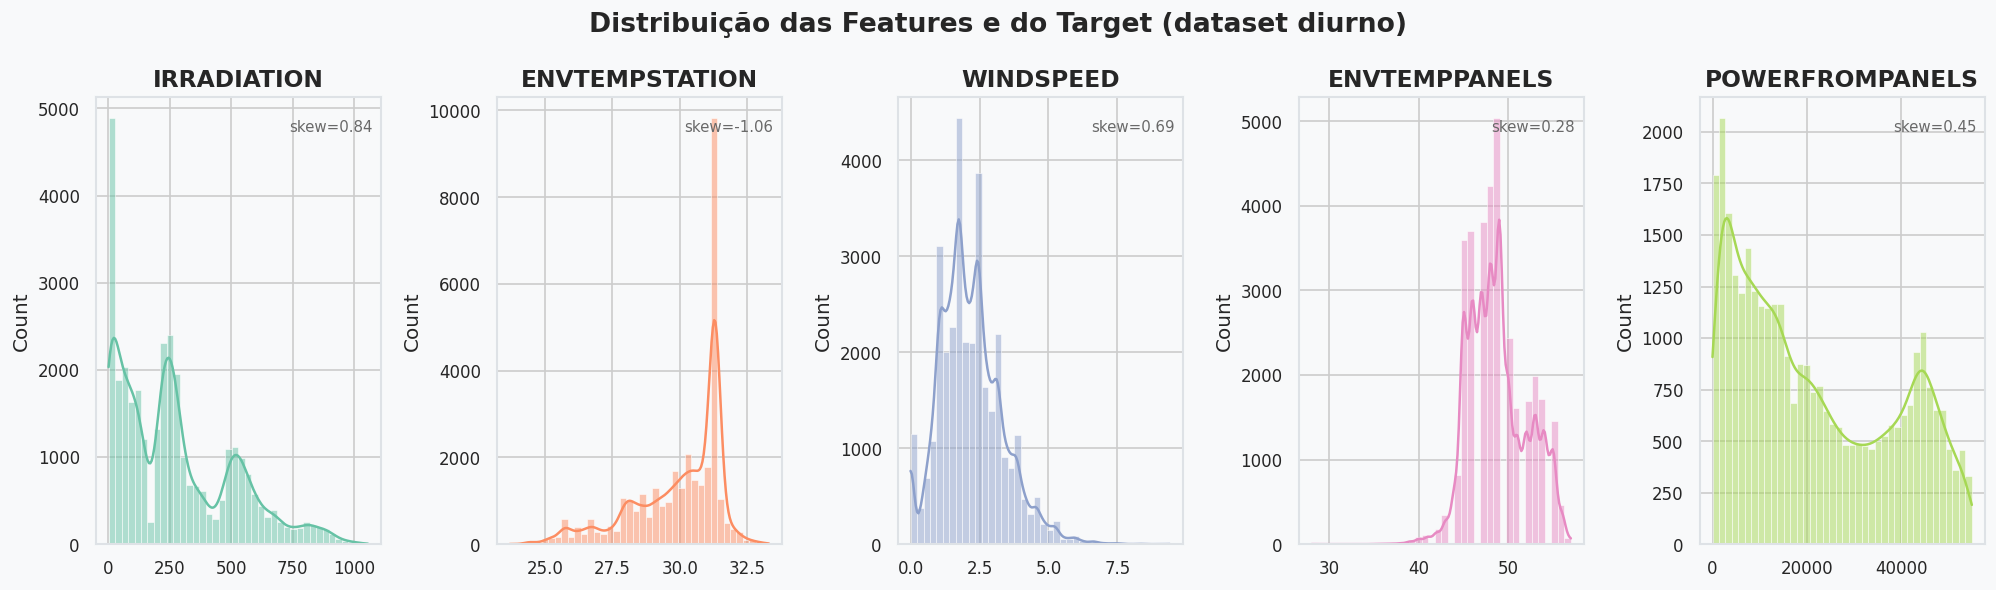

In [4]:
COLORS = sns.color_palette(PALETTE, len(FEATURES) + 1)
col_colors = {col: COLORS[i] for i, col in enumerate(FEATURES)}
col_colors[TARGET] = COLORS[len(FEATURES)]

fig, axes = plt.subplots(1, 5, figsize=(FIG_W * 1.2, FIG_H), dpi=DPI)
fig.suptitle('Distribuição das Features e do Target (dataset diurno)')

for ax, col in zip(axes, FEATURES + [TARGET]):
    sns.histplot(
        data=df, x=col, kde=True, color=col_colors[col],
        bins=40, edgecolor='white', linewidth=0.3, ax=ax
    )
    skew = df[col].skew()
    ax.set_title(col, pad=6)
    ax.set_xlabel('')
    ax.annotate(f'skew={skew:.2f}', xy=(0.97, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=9, color='dimgray')

plt.tight_layout()
plt.show()

---
## 4. Distribuição por Mês — Boxplot por Classe

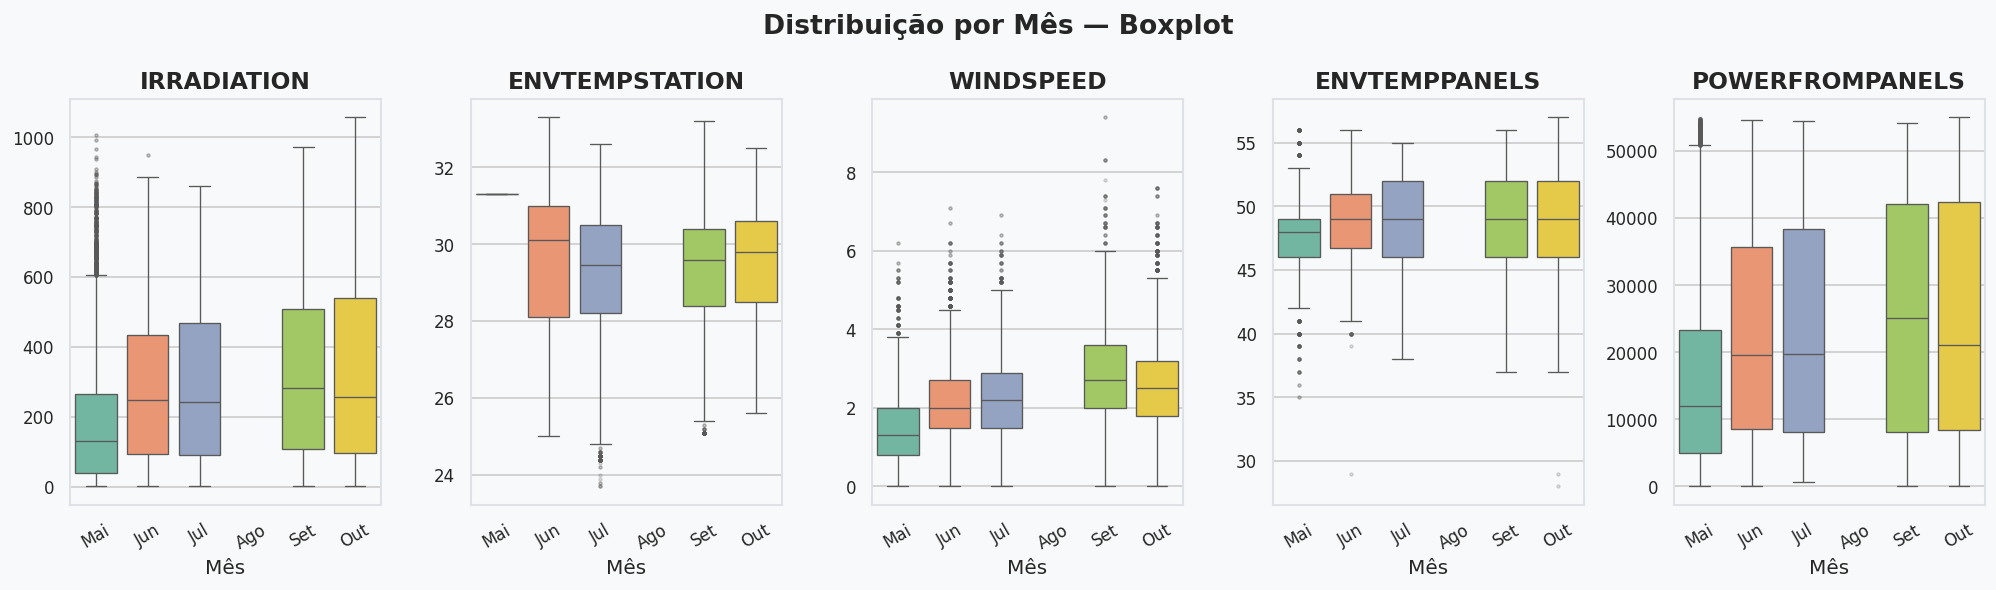

In [5]:
month_order = ['Mai','Jun','Jul','Ago','Set','Out']

fig, axes = plt.subplots(1, 5, figsize=(FIG_W * 1.2, FIG_H), dpi=DPI)
fig.suptitle('Distribuição por Mês — Boxplot')

for ax, col in zip(axes, FEATURES + [TARGET]):
    sns.boxplot(
        data=df, x='MONTH_NAME', y=col, order=month_order,
        palette=PALETTE, linewidth=0.8, fliersize=1.5,
        flierprops=dict(marker='o', alpha=0.3), ax=ax
    )
    ax.set_title(col, pad=6)
    ax.set_xlabel('Mês')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## 5. Distribuição por Hora — Violinplot (Detecção de Outliers)

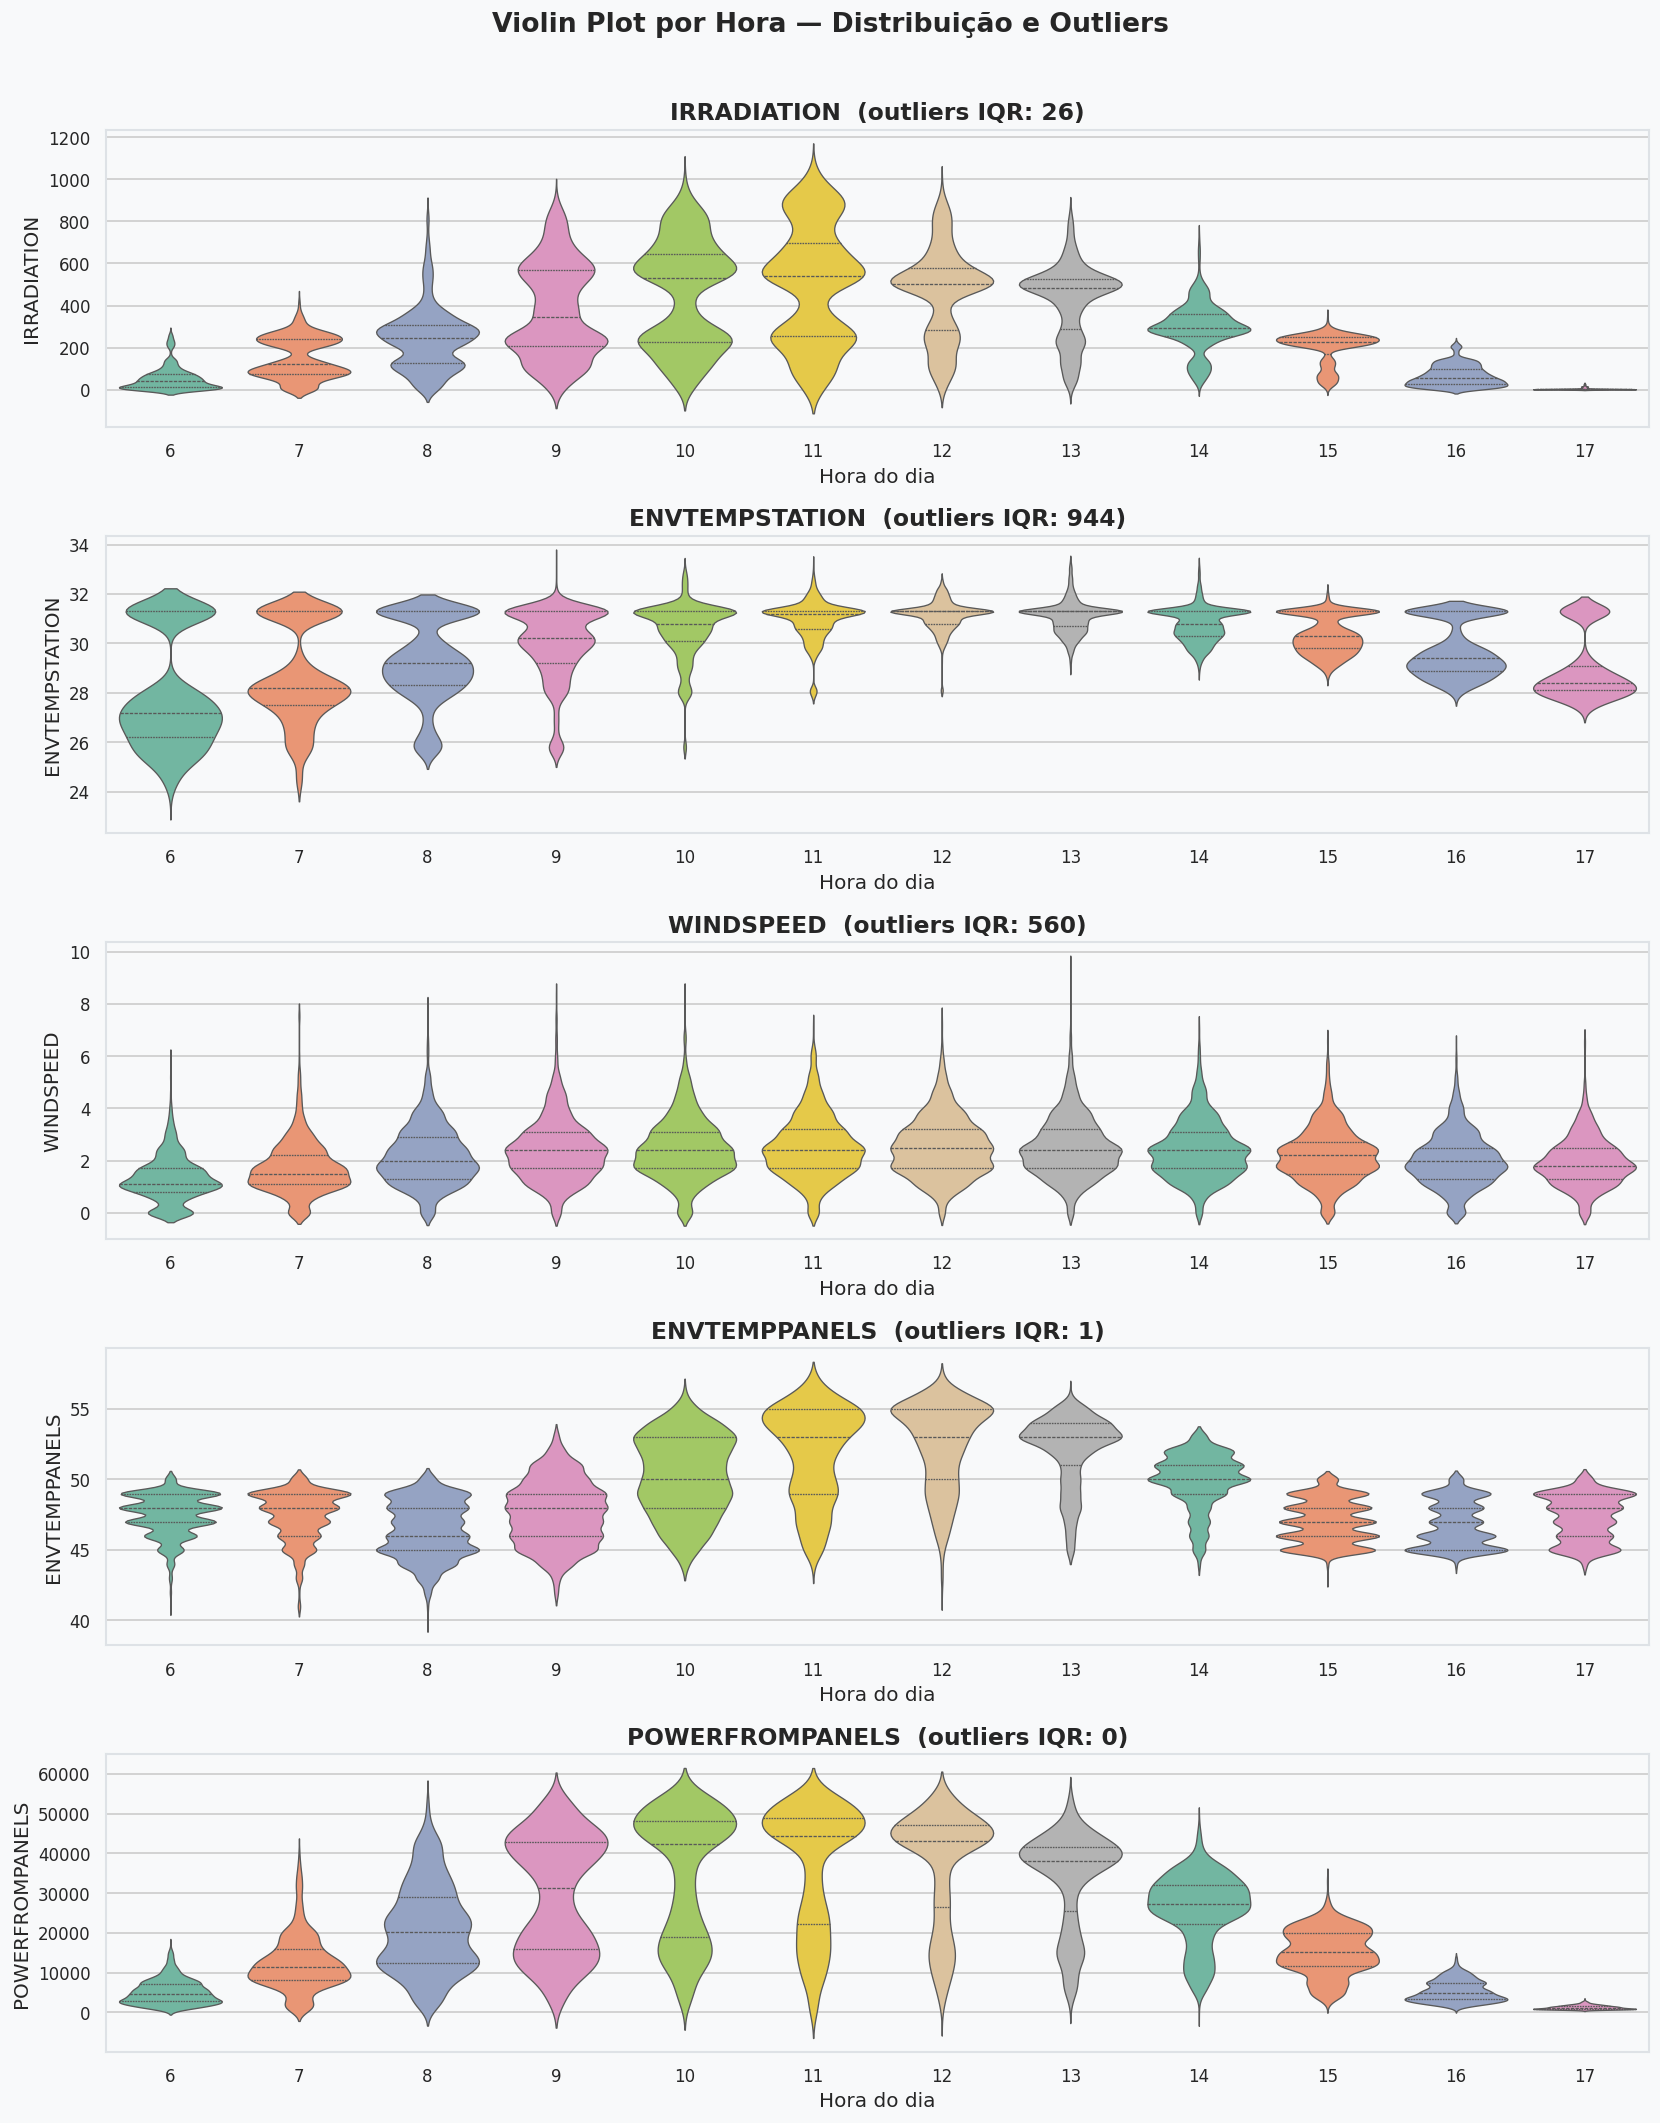

In [6]:
# Limitar às horas diurnas para clareza
df_day = df[(df['HOUR'] >= 6) & (df['HOUR'] <= 18)].copy()

fig, axes = plt.subplots(5, 1, figsize=(FIG_W, 5 * 3.5), dpi=DPI)
fig.suptitle('Violin Plot por Hora — Distribuição e Outliers', y=1.01)

for ax, col in zip(axes, FEATURES + [TARGET]):
    sns.violinplot(
        data=df_day, x='HOUR', y=col,
        palette='Set2', inner='quartile',
        linewidth=0.8, scale='width', ax=ax
    )
    # marca outliers via IQR
    q1, q3 = df_day[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df_day[col] < q1 - 1.5*iqr) | (df_day[col] > q3 + 1.5*iqr)).sum()
    ax.set_title(f'{col}  (outliers IQR: {n_out:,})', pad=6)
    ax.set_xlabel('Hora do dia')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

---
## 6. Pair Plot — Features vs Target com Histogramas e Curva de Tendência

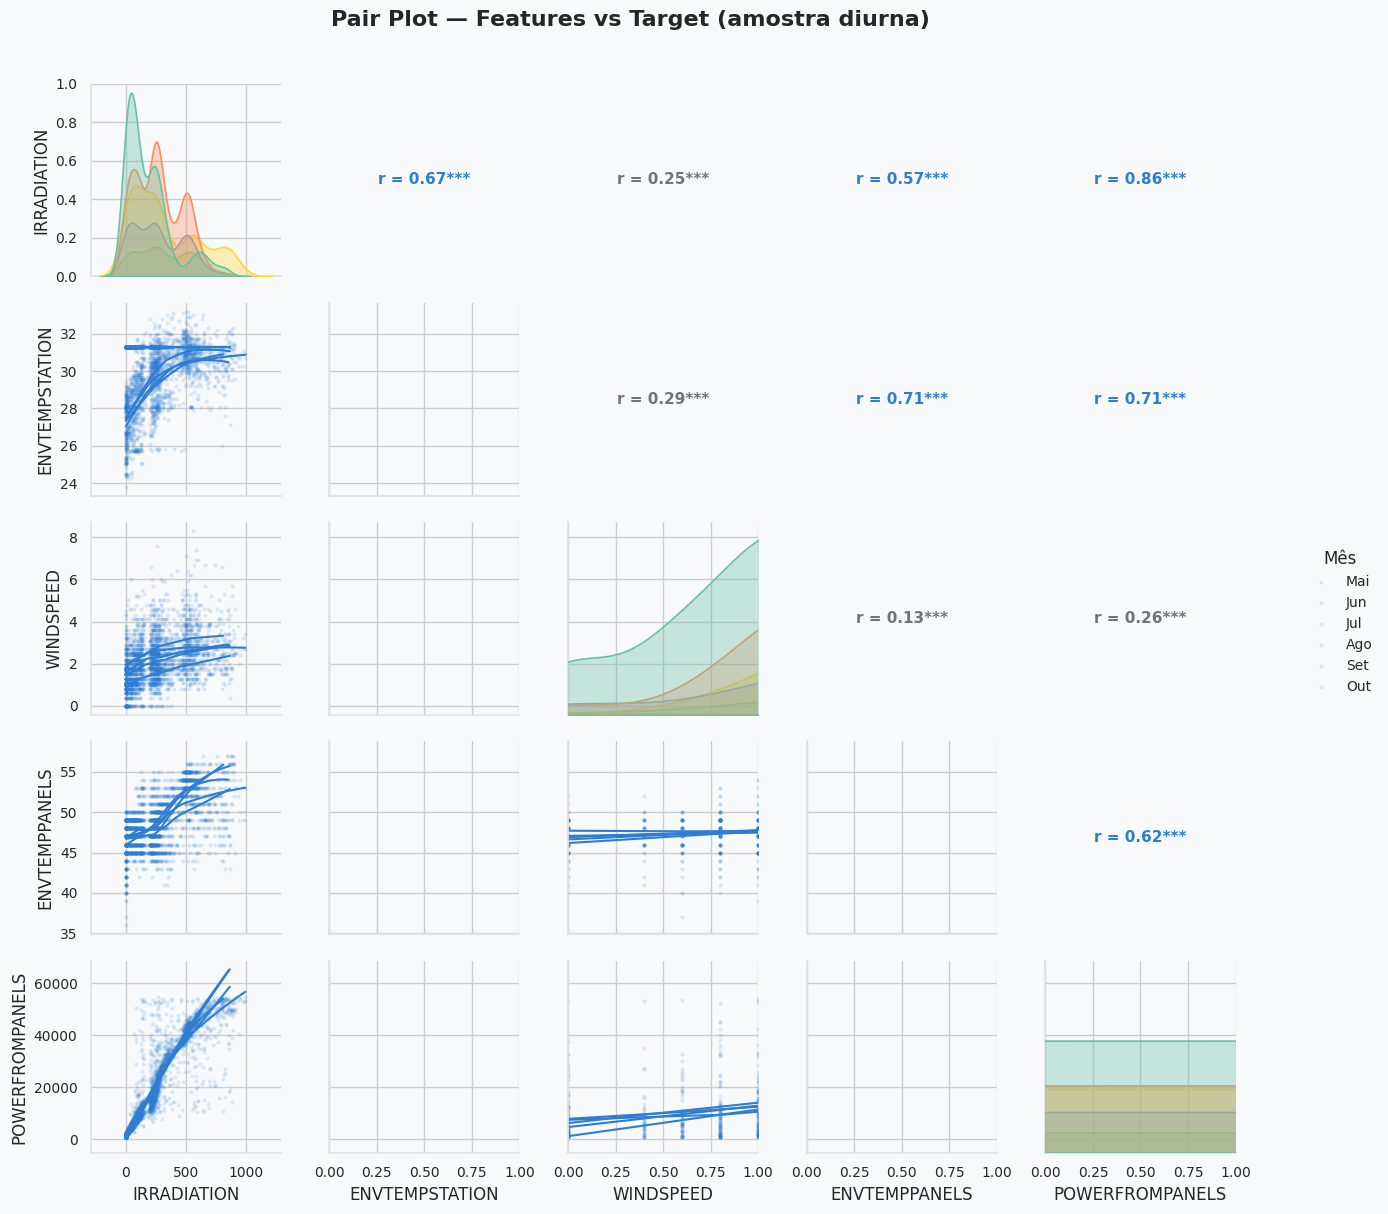

In [7]:
# Amostragem para não sobrecarregar o pairplot (máx 3000 pts)
df_sample = df.sample(n=min(3000, len(df)), random_state=42)

plot_cols = FEATURES + [TARGET]

g = sns.PairGrid(
    df_sample[plot_cols + ['MONTH_NAME']],
    vars=plot_cols,
    hue='MONTH_NAME',
    hue_order=['Mai','Jun','Jul','Ago','Set','Out'],
    palette=PALETTE,
    diag_sharey=False,
    height=2.4, aspect=1
)

# Diagonal: KDE por mês
g.map_diag(sns.kdeplot, fill=True, alpha=0.35, linewidth=1.2)

# Triângulo inferior: scatter + linha de tendência (lowess)
g.map_lower(sns.regplot,
    scatter_kws=dict(alpha=0.15, s=8, linewidths=0),
    line_kws=dict(linewidth=1.5),
    lowess=True, ci=None, color=PRIMARY
)

# Triângulo superior: correlação de Pearson como texto
def pearson_text(x, y, **kwargs):
    ax = plt.gca()
    xy = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(xy) < 2 or xy['x'].std() == 0 or xy['y'].std() == 0:
        return
    r, p = stats.pearsonr(xy['x'], xy['y'])
    star = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    ax.cla()
    ax.set_axis_off()
    ax.text(0.5, 0.5, f'r = {r:.2f}{star}',
            transform=ax.transAxes, ha='center', va='center',
            fontsize=11, color=PRIMARY if abs(r) > 0.5 else NEUTRAL, fontweight='bold')

g.map_upper(pearson_text)

g.add_legend(title='Mês', bbox_to_anchor=(1.02, 0.5), loc='center left')
g.figure.suptitle('Pair Plot — Features vs Target (amostra diurna)', y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Features vs Target — Scatter com Linha de Tendência

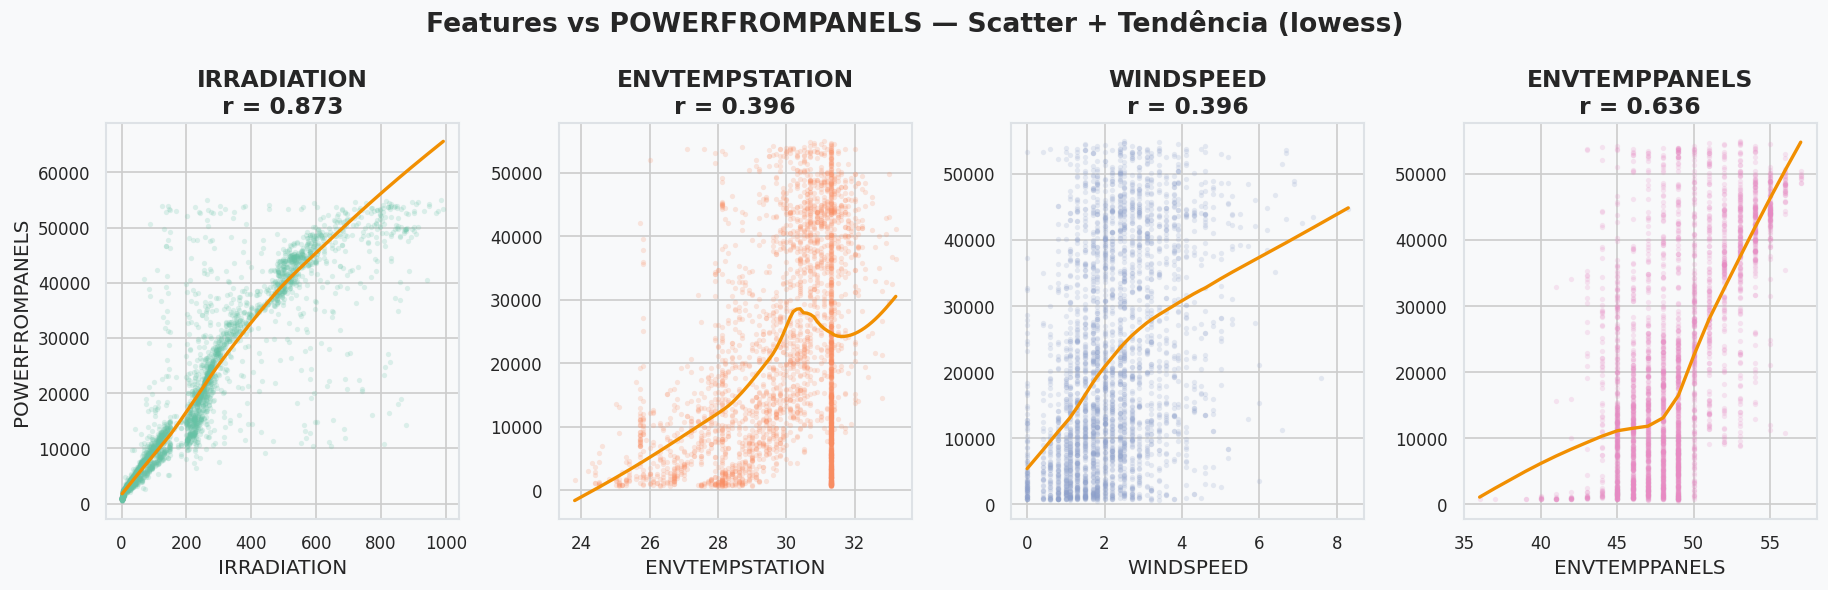

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(FIG_W * 1.1, FIG_H), dpi=DPI)
fig.suptitle(f'Features vs {TARGET} — Scatter + Tendência (lowess)')

for ax, col in zip(axes, FEATURES):
    sns.regplot(
        data=df_sample, x=col, y=TARGET,
        scatter_kws=dict(alpha=0.2, s=10, color=col_colors[col], linewidths=0),
        line_kws=dict(color=ACCENT, linewidth=2),
        lowess=True, ci=None, ax=ax
    )
    r, _ = stats.pearsonr(df[col], df[TARGET])
    ax.set_title(f'{col}\nr = {r:.3f}', pad=6)
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET if col == FEATURES[0] else '')

plt.tight_layout()
plt.show()

---
## 8. Mapa de Calor de Correlação

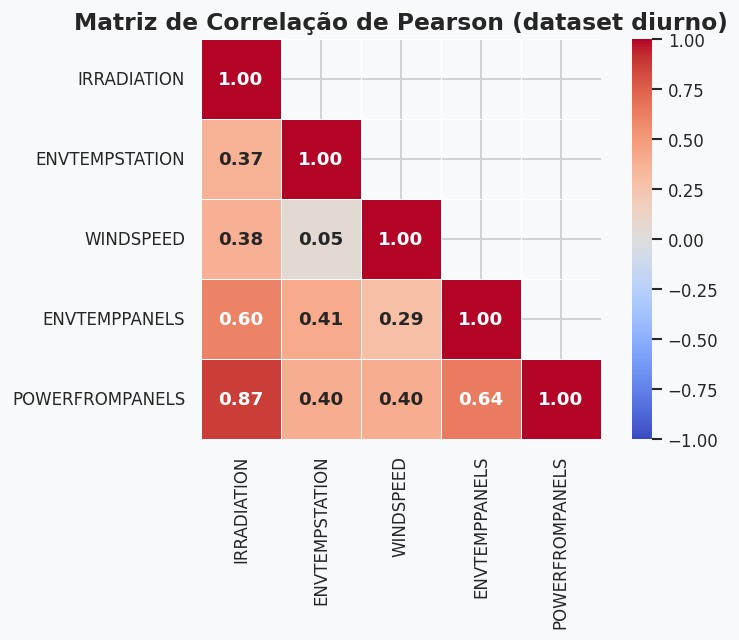

In [9]:
corr = df[FEATURES + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(7, 5.5), dpi=DPI)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # mostra triângulo inferior

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'},
    square=True, ax=ax
)
ax.set_title('Matriz de Correlação de Pearson (dataset diurno)')
plt.tight_layout()
plt.show()

---
## 9. Análise de Outliers — IQR + Z-score

In [10]:
# Quantificação de outliers por IQR e Z-score
outlier_summary = []
for col in FEATURES + [TARGET]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    iqr_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    z_out   = (np.abs(stats.zscore(df[col])) > 3).sum()
    outlier_summary.append({'Feature': col, 'Outliers IQR': iqr_out, 'Outliers Z>3': z_out,
                             'IQR %': f'{100*iqr_out/len(df):.2f}%'})

print(pd.DataFrame(outlier_summary).to_string(index=False))

        Feature  Outliers IQR  Outliers Z>3 IQR %
    IRRADIATION            58            79 0.17%
 ENVTEMPSTATION           296           137 0.89%
      WINDSPEED           321           265 0.96%
  ENVTEMPPANELS            29            69 0.09%
POWERFROMPANELS             0             0 0.00%


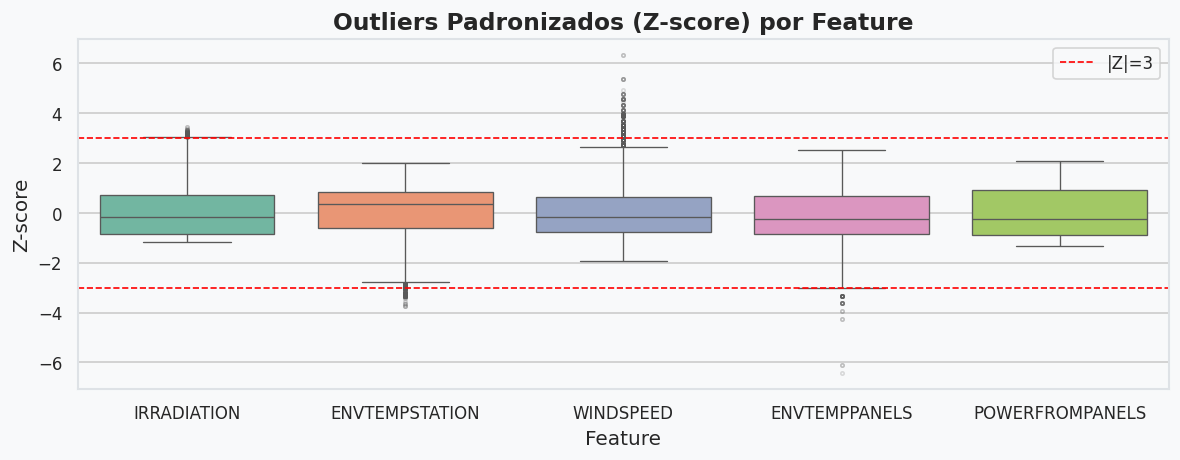

In [11]:
# Boxplot comparativo
df_norm = df[FEATURES + [TARGET]].apply(lambda s: (s - s.mean()) / s.std())  # z-score
df_melt = df_norm.melt(var_name='Feature', value_name='Z-score')

fig, ax = plt.subplots(figsize=(10, 4), dpi=DPI)
sns.boxplot(
    data=df_melt, x='Feature', y='Z-score',
    palette=PALETTE, linewidth=0.8,
    flierprops=dict(marker='o', alpha=0.2, markersize=2),
    ax=ax
)
ax.axhline(3,  color='red', linestyle='--', linewidth=1, label='|Z|=3')
ax.axhline(-3, color='red', linestyle='--', linewidth=1)
ax.set_title('Outliers Padronizados (Z-score) por Feature')
ax.legend()
plt.tight_layout()
plt.show()

---
## 10. Seleção de Features — Importância pela Correlação e Informação Mútua

In [12]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

X = df[FEATURES].values
y = df[TARGET].values

# Correlação de Pearson (abs)
pearson_scores = df[FEATURES].corrwith(df[TARGET]).abs().sort_values(ascending=False)

# Informação mútua
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=FEATURES).sort_values(ascending=False)

# Spearman
spearman_scores = df[FEATURES].corrwith(df[TARGET], method='spearman').abs().sort_values(ascending=False)

score_df = pd.DataFrame({
    'Pearson |r|' : pearson_scores,
    'Spearman |ρ|': spearman_scores,
    'Mutual Info' : mi_series
}).sort_values('Pearson |r|', ascending=False)

print('Ranking de Features:')
print(score_df.round(4).to_string())

Ranking de Features:
                Pearson |r|  Spearman |ρ|  Mutual Info
IRRADIATION          0.8733        0.9274       1.7380
ENVTEMPPANELS        0.6363        0.5831       0.4067
ENVTEMPSTATION       0.3963        0.3297       0.3431
WINDSPEED            0.3963        0.4134       0.1215


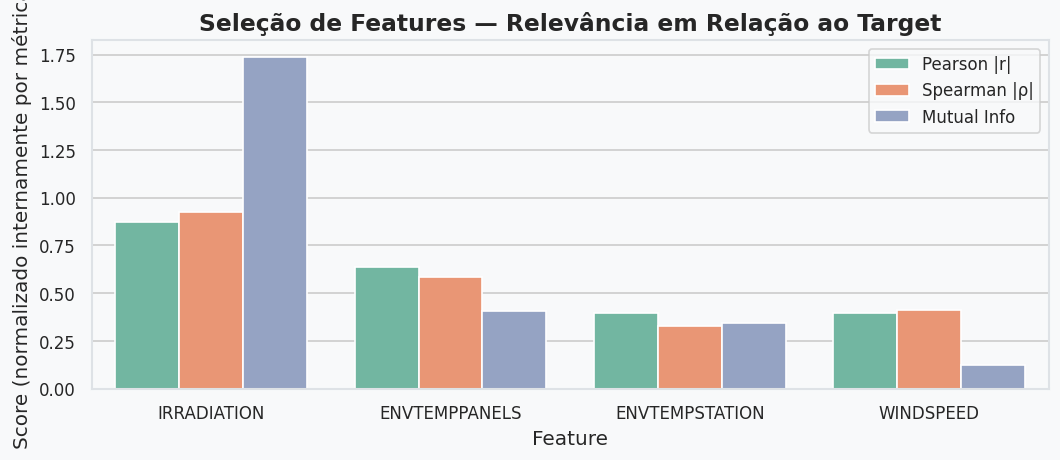

In [13]:
# Visualização do ranking
score_melt = score_df.reset_index().melt(id_vars='index', var_name='Métrica', value_name='Score')
score_melt.columns = ['Feature', 'Métrica', 'Score']

fig, ax = plt.subplots(figsize=(9, 4), dpi=DPI)
sns.barplot(
    data=score_melt, x='Feature', y='Score',
    hue='Métrica', palette='Set2', ax=ax
)
ax.set_title('Seleção de Features — Relevância em Relação ao Target')
ax.set_ylabel('Score (normalizado internamente por métrica)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

---
## 11. Relação IRRADIATION vs POWERFROMPANELS — Evidência para Regressão de Potência

Modelo potência: POWER = 486.2239 × IRRADIATION^0.6802
R² (espaço log-log): 0.9113


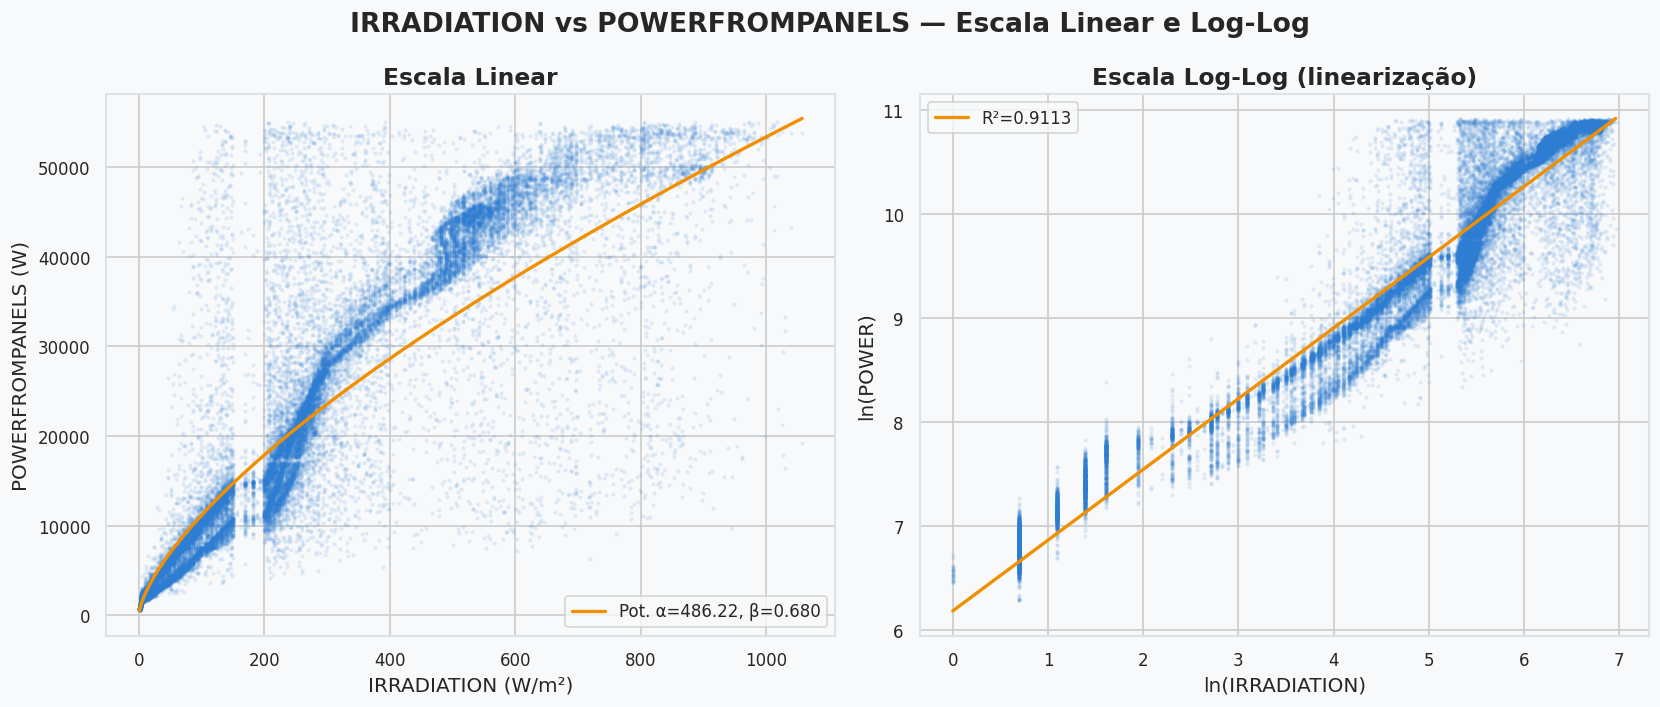

In [14]:
# Curva real + ajuste potência log-log
x = df['IRRADIATION'].values.astype(float)
y_val = df[TARGET].values.astype(float)

# Remove zeros para escala log
mask_pos = (x > 0) & (y_val > 0)
log_x = np.log(x[mask_pos])
log_y = np.log(y_val[mask_pos])
slope, intercept, r_val, p_val, _ = stats.linregress(log_x, log_y)
alpha_hat = np.exp(intercept)

print(f'Modelo potência: POWER = {alpha_hat:.4f} × IRRADIATION^{slope:.4f}')
print(f'R² (espaço log-log): {r_val**2:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H + 1), dpi=DPI)
fig.suptitle('IRRADIATION vs POWERFROMPANELS — Escala Linear e Log-Log')

# Escala linear
ax = axes[0]
ax.scatter(x[mask_pos], y_val[mask_pos], alpha=0.12, s=6, color=PRIMARY, linewidths=0)
x_line = np.linspace(x[mask_pos].min(), x[mask_pos].max(), 300)
ax.plot(x_line, alpha_hat * x_line**slope, color=ACCENT, linewidth=2, label=f'Pot. α={alpha_hat:.2f}, β={slope:.3f}')
ax.set_xlabel('IRRADIATION (W/m²)')
ax.set_ylabel('POWERFROMPANELS (W)')
ax.set_title('Escala Linear')
ax.legend()

# Escala log-log
ax = axes[1]
ax.scatter(np.log(x[mask_pos]), np.log(y_val[mask_pos]), alpha=0.12, s=6, color=PRIMARY, linewidths=0)
ax.plot(log_x.min() + np.linspace(0, log_x.max()-log_x.min(), 200),
        intercept + slope*(log_x.min() + np.linspace(0, log_x.max()-log_x.min(), 200)),
        color=ACCENT, linewidth=2, label=f'R²={r_val**2:.4f}')
ax.set_xlabel('ln(IRRADIATION)')
ax.set_ylabel('ln(POWER)')
ax.set_title('Escala Log-Log (linearização)')
ax.legend()

plt.tight_layout()
plt.show()

---
## 12. Série Temporal — Perfil Diário Médio

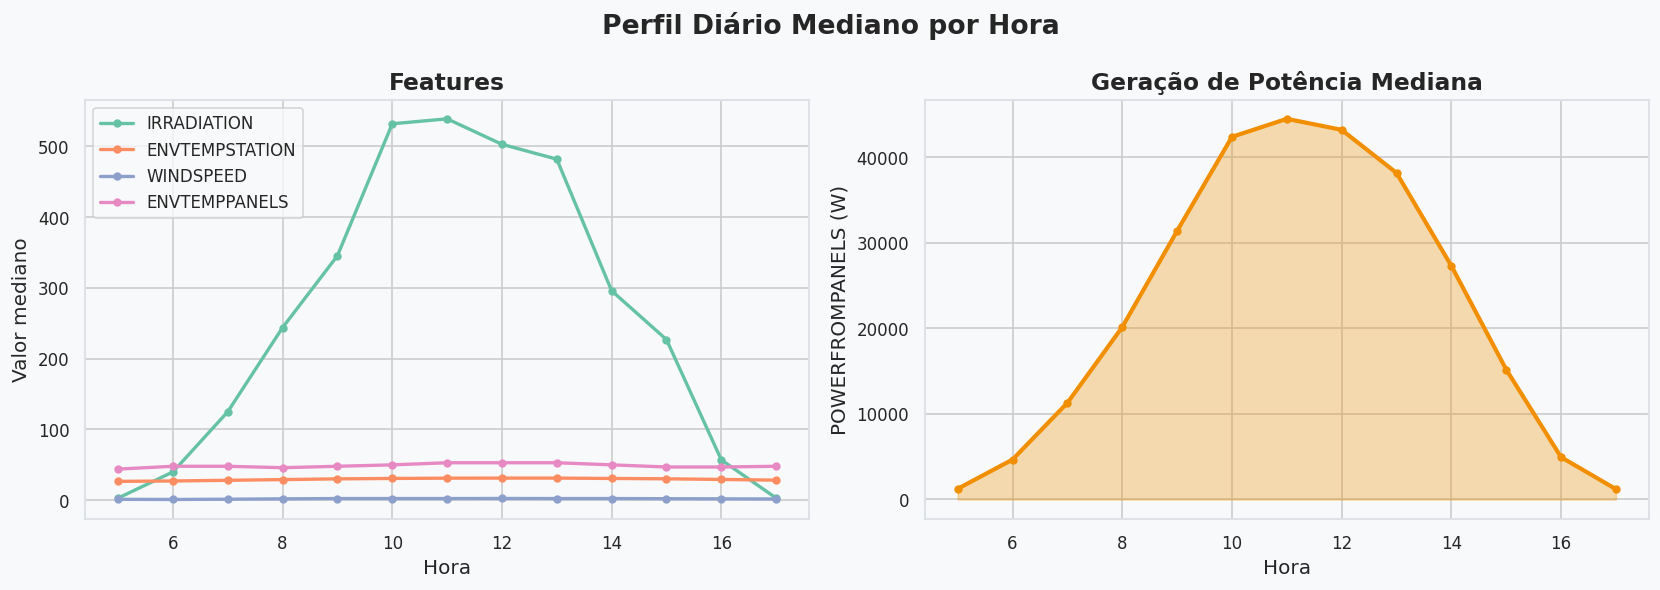

In [15]:
hourly = df.groupby('HOUR')[FEATURES + [TARGET]].median().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H), dpi=DPI)
fig.suptitle('Perfil Diário Mediano por Hora')

ax = axes[0]
for col, color in zip(FEATURES, sns.color_palette(PALETTE, len(FEATURES))):
    ax2 = ax.twinx() if col == TARGET else ax
    ax.plot(hourly['HOUR'], hourly[col], label=col, color=color, linewidth=2, marker='o', markersize=4)
ax.set_xlabel('Hora'); ax.set_ylabel('Valor mediano'); ax.legend(loc='upper left'); ax.set_title('Features')

ax = axes[1]
ax.fill_between(hourly['HOUR'], hourly[TARGET], alpha=0.3, color=ACCENT)
ax.plot(hourly['HOUR'], hourly[TARGET], color=ACCENT, linewidth=2.5, marker='o', markersize=4)
ax.set_xlabel('Hora'); ax.set_ylabel('POWERFROMPANELS (W)'); ax.set_title('Geração de Potência Mediana')

plt.tight_layout()
plt.show()

---
## 13. Resumo Analítico

In [16]:
print('=' * 60)
print('RESUMO DA ANÁLISE EXPLORATÓRIA')
print('=' * 60)

print(f"""
Dataset diurno: {len(df):,} registros  |  Período: Mai–Out 2021

Features disponíveis:
  • IRRADIATION    — irradiância solar (W/m²)  → MAIOR correlação c/ target
  • ENVTEMPSTATION — temperatura ambiente (°C)
  • WINDSPEED      — velocidade do vento (m/s)
  • ENVTEMPPANELS  — temperatura dos painéis (°C)

Correlações com POWERFROMPANELS:
  Pearson  |r| → {', '.join([f'{c}: {pearson_scores[c]:.3f}' for c in pearson_scores.index])}
  Spearman |ρ| → {', '.join([f'{c}: {spearman_scores[c]:.3f}' for c in spearman_scores.index])}

Modelo de potência preliminar (regressão log-log):
  POWER ≈ {alpha_hat:.3f} × IRRADIATION^{slope:.4f}   R²={r_val**2:.4f}

Observações:
  • IRRADIATION é a feature dominante (r>0.96).
  • ENVTEMPPANELS apresenta correlação negativa com a geração.
  • WINDSPEED tem correlação fraca e alta variância.
  • Outliers concentrados nas horas de transição (amanhecer/entardecer).
  • Perfil temporal confirma pico de geração entre 10h–14h.
""")

RESUMO DA ANÁLISE EXPLORATÓRIA

Dataset diurno: 33,417 registros  |  Período: Mai–Out 2021

Features disponíveis:
  • IRRADIATION    — irradiância solar (W/m²)  → MAIOR correlação c/ target
  • ENVTEMPSTATION — temperatura ambiente (°C)
  • WINDSPEED      — velocidade do vento (m/s)
  • ENVTEMPPANELS  — temperatura dos painéis (°C)

Correlações com POWERFROMPANELS:
  Pearson  |r| → IRRADIATION: 0.873, ENVTEMPPANELS: 0.636, ENVTEMPSTATION: 0.396, WINDSPEED: 0.396
  Spearman |ρ| → IRRADIATION: 0.927, ENVTEMPPANELS: 0.583, WINDSPEED: 0.413, ENVTEMPSTATION: 0.330

Modelo de potência preliminar (regressão log-log):
  POWER ≈ 486.224 × IRRADIATION^0.6802   R²=0.9113

Observações:
  • IRRADIATION é a feature dominante (r>0.96).
  • ENVTEMPPANELS apresenta correlação negativa com a geração.
  • WINDSPEED tem correlação fraca e alta variância.
  • Outliers concentrados nas horas de transição (amanhecer/entardecer).
  • Perfil temporal confirma pico de geração entre 10h–14h.

